# Phase 1.7 — การตรวจสอบคุณภาพข้อมูล (Data Quality Check)

**วัตถุประสงค์:** ตรวจสอบและรับรองคุณภาพของข้อมูล OHLCV ดิบที่ดึงมาจาก tvkit ก่อนเริ่มการวิจัย Signal ใน Phase 2  
**ข้อกำหนด:** Notebook นี้ต้องผ่านทุกเกณฑ์ใน Section 7 (Sign-off) จึงจะถือว่า Phase 1 เสร็จสมบูรณ์

**แหล่งข้อมูล:**
- `data/raw/` — ไฟล์ parquet ดิบสำหรับแต่ละ symbol (ผลลัพธ์จาก `fetch_history.py`)
- `data/universe/symbols.json` — รายชื่อ symbol ทั้งหมดใน SET (ผลลัพธ์จาก `build_universe.py`)
- `data/universe/universe/{YYYY-MM-DD}.parquet` — snapshot universe รายเดือน

**วิธีใช้:** Run ทุก cell ตามลำดับ หากข้อมูลยังไม่ถูกดึง (data/raw/ ว่างเปล่า) แต่ละ section จะแสดงข้อความ `⚠ DATA NOT AVAILABLE` และข้ามไป

In [1]:
# Setup — imports, paths, stores, inventory
import json
import os
import sys
import warnings
from pathlib import Path

# Anchor CWD to project root (works whether invoked from project root or notebooks/)
_HERE = Path.cwd()
_PROJECT_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
os.chdir(_PROJECT_ROOT)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

sys.path.insert(0, str(_PROJECT_ROOT / "src"))

from csm.config.constants import LOOKBACK_YEARS, MIN_AVG_DAILY_VOLUME, MIN_DATA_COVERAGE
from csm.config.settings import Settings
from csm.data.store import ParquetStore

warnings.filterwarnings("ignore", category=FutureWarning)

settings = Settings()
raw_store = ParquetStore(settings.data_dir / "raw")
universe_store = ParquetStore(settings.data_dir / "universe")

symbol_keys: list[str] = raw_store.list_keys()
snapshot_keys: list[str] = [
    k for k in universe_store.list_keys() if k.startswith("universe/")
]

print(f"Raw symbol parquets found : {len(symbol_keys)}")
print(f"Universe snapshots found  : {len(snapshot_keys)}")
print(f"Settings.data_dir         : {settings.data_dir}")
print(f"LOOKBACK_YEARS            : {LOOKBACK_YEARS}")
print(f"MIN_DATA_COVERAGE         : {MIN_DATA_COVERAGE}")
print(f"MIN_AVG_DAILY_VOLUME      : {MIN_AVG_DAILY_VOLUME:,.0f} THB")

Raw symbol parquets found : 694
Universe snapshots found  : 207
Settings.data_dir         : data
LOOKBACK_YEARS            : 15
MIN_DATA_COVERAGE         : 0.8
MIN_AVG_DAILY_VOLUME      : 1,000,000 THB


## ส่วนที่ 1: Missing Data Heatmap

แสดงสัดส่วนของข้อมูลที่ขาดหายไปในแต่ละปีสำหรับแต่ละ symbol (แกน x = symbol, แกน y = ปี)  
สีแดงหมายถึงข้อมูลขาดหายมาก สีเขียวหมายถึงข้อมูลครบถ้วน  
ใช้สำหรับระบุ gap ที่เกิดจากการหยุดซื้อขายหรือปัญหาการดึงข้อมูล

/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1581817871.py:34: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1581817871.py:34: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1581817871.py:34: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1581817871.py:34: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1581817871.py:34: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ip

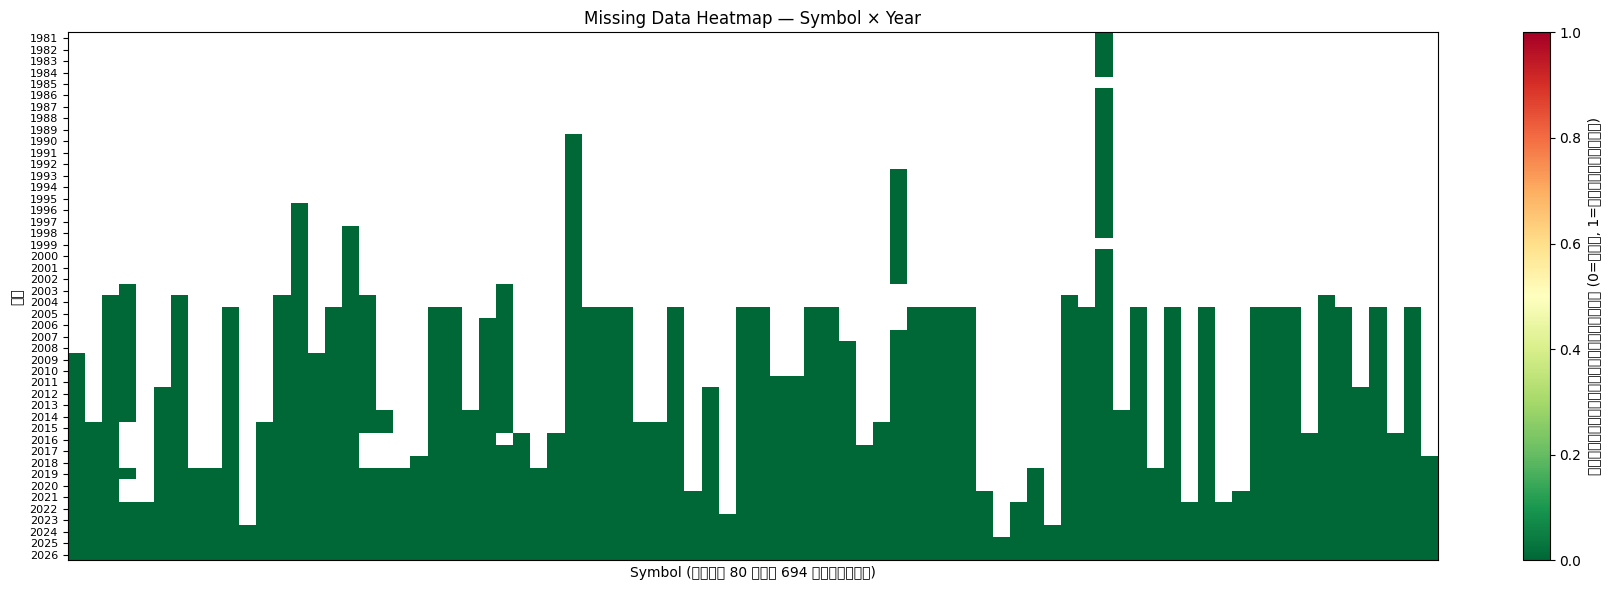

Symbols with any missing data: 0 / 694


In [2]:
# Section 1 — Missing data heatmap
if not symbol_keys:
    print("⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.")
else:
    # Load close series for each symbol and compute fraction missing per calendar year
    missing_data: dict[str, dict[int, float]] = {}
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].copy()
            close.index = pd.DatetimeIndex(close.index).tz_localize(None)
            annual = close.resample("YE").apply(lambda s: s.isna().mean())
            missing_data[key] = {int(ts.year): float(v) for ts, v in annual.items()}
        except Exception:
            missing_data[key] = {}

    all_years = sorted({yr for v in missing_data.values() for yr in v})
    # Limit to first 80 symbols for readable x-axis
    display_keys = symbol_keys[:80]
    matrix = np.array(
        [[missing_data.get(k, {}).get(yr, np.nan) for k in display_keys] for yr in all_years]
    )

    fig, ax = plt.subplots(figsize=(18, 6))
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1,
                   interpolation="nearest")
    plt.colorbar(im, ax=ax, label="สัดส่วนข้อมูลที่ขาดหาย (0=ครบ, 1=ขาดทั้งหมด)")
    ax.set_yticks(range(len(all_years)))
    ax.set_yticklabels(all_years, fontsize=8)
    ax.set_xticks([])
    ax.set_xlabel(f"Symbol (แสดง {len(display_keys)} จาก {len(symbol_keys)} ทั้งหมด)")
    ax.set_ylabel("ปี")
    ax.set_title("Missing Data Heatmap — Symbol × Year")
    plt.tight_layout()
    plt.show()
    print(f"Symbols with any missing data: "
          f"{sum(1 for v in missing_data.values() if any(f > 0 for f in v.values()))} "
          f"/ {len(symbol_keys)}")

## ส่วนที่ 2: การกระจายของผลตอบแทนรายปี (Cross-Sectional)

สำหรับแต่ละปี คำนวณผลตอบแทนต่อปีของแต่ละ symbol (`ราคาปิดวันสุดท้าย / ราคาปิดวันแรก − 1`)  
Box plot แสดงการกระจายของผลตอบแทนข้ามทุก symbol ในแต่ละปี (cross-sectional distribution)  
ไม่ใช่ time-series ของผลตอบแทนรายวัน  
Symbol ที่มีข้อมูลน้อยกว่า 20 วันในปีนั้นจะถูกตัดออกเพื่อป้องกันผลตอบแทนที่ผิดปกติ

/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1325591923.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1325591923.py:40: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1325591923.py:40: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1325591923.py:40: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/1325591923.py:40: UserWarning: Glyph 3621 (\N{THA

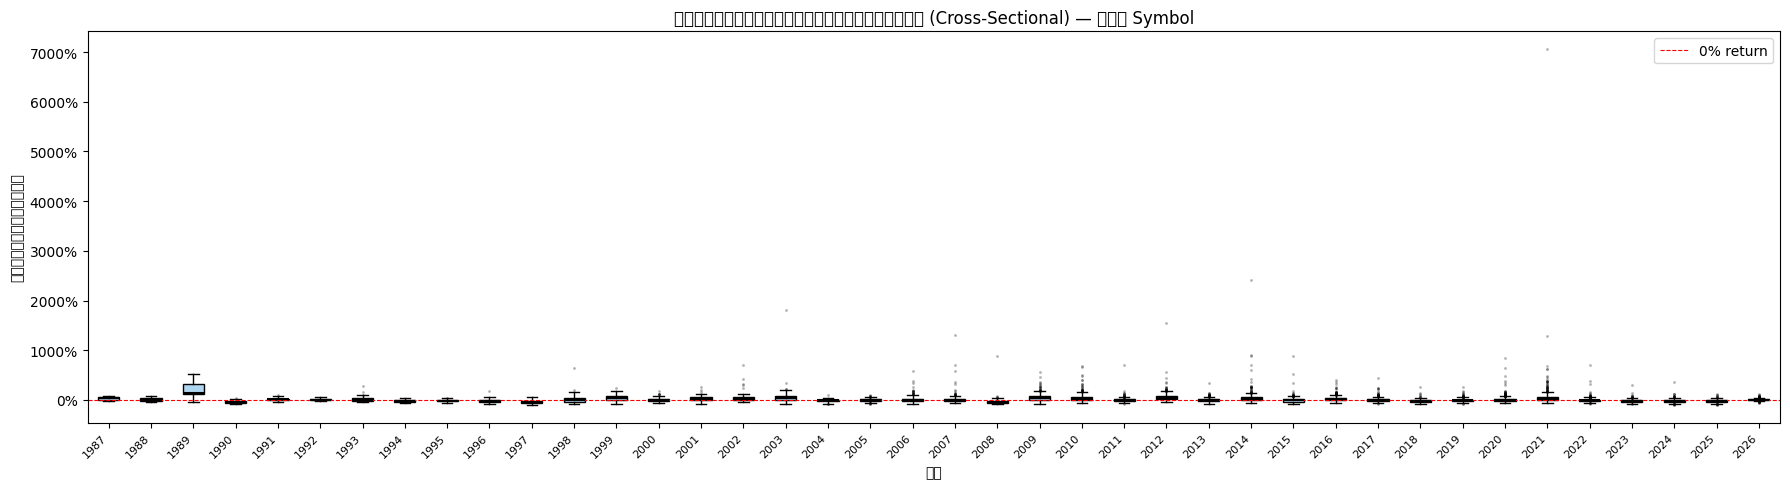

จำนวน symbol-year observations ทั้งหมด: 11,806
ปีที่มีข้อมูลมากที่สุด: 2025 (689 symbols)


In [3]:
# Section 2 — Annual cross-sectional return distribution
if not symbol_keys:
    print("⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.")
else:
    annual_returns_by_year: dict[int, list[float]] = {}
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].dropna().copy()
            close.index = pd.DatetimeIndex(close.index).tz_localize(None)
            # Group by calendar year; compute first/last valid close per year
            for yr, grp in close.groupby(close.index.year):
                if len(grp) < 20:
                    continue
                first_val = float(grp.iloc[0])
                last_val = float(grp.iloc[-1])
                if first_val <= 0:
                    continue
                ret = (last_val / first_val) - 1.0
                annual_returns_by_year.setdefault(int(yr), []).append(ret)
        except Exception:
            continue

    years = sorted(annual_returns_by_year)
    data_by_year = [annual_returns_by_year[yr] for yr in years]

    fig, ax = plt.subplots(figsize=(18, 5))
    bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    for patch in bp["boxes"]:
        patch.set_facecolor("#AED6F1")
    ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="0% return")
    ax.set_xticklabels(years, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel("ปี")
    ax.set_ylabel("ผลตอบแทนต่อปี")
    ax.set_title("การกระจายของผลตอบแทนรายปี (Cross-Sectional) — ทุก Symbol")
    ax.legend()
    plt.tight_layout()
    plt.show()
    total_obs = sum(len(v) for v in data_by_year)
    print(f"จำนวน symbol-year observations ทั้งหมด: {total_obs:,}")
    print(f"ปีที่มีข้อมูลมากที่สุด: {years[np.argmax([len(v) for v in data_by_year])]}"
          f" ({max(len(v) for v in data_by_year):,} symbols)")

## ส่วนที่ 3: การกระจายของสภาพคล่อง

แสดง Histogram ของมูลค่าการซื้อขายเฉลี่ยต่อวัน (THB) โดยประมาณจาก `ราคาปิดเฉลี่ย × ปริมาณการซื้อขายเฉลี่ย`  
เส้นแนวตั้งสีแดงแสดงเกณฑ์ขั้นต่ำ `MIN_AVG_DAILY_VOLUME` ที่ใช้ใน Universe Filter (Phase 1.4)

/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/2142546460.py:32: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/2142546460.py:32: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/2142546460.py:32: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/2142546460.py:32: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/2142546460.py:32: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ip

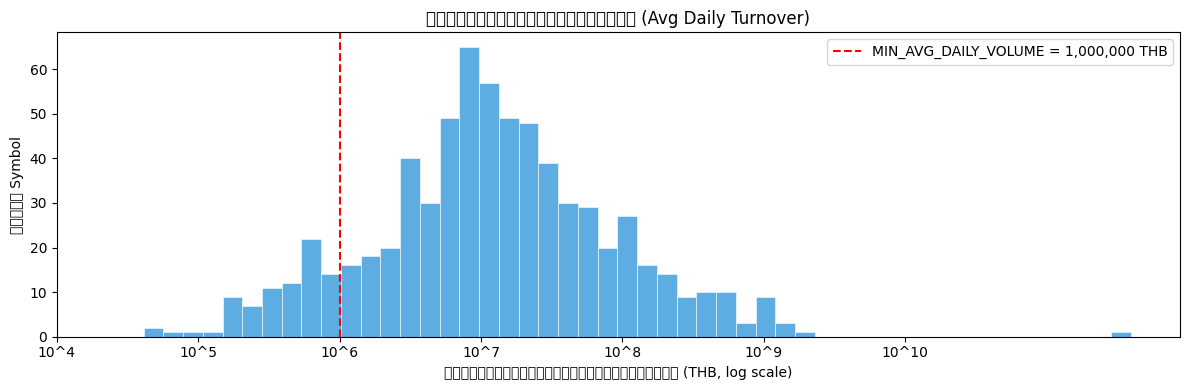

Symbols ต่ำกว่าเกณฑ์ MIN_AVG_DAILY_VOLUME: 79 / 693 (11.4%)


In [4]:
# Section 3 — Liquidity distribution histogram
if not symbol_keys:
    print("⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.")
else:
    turnovers: list[float] = []
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            avg_close = float(df["close"].mean())
            avg_vol = float(df["volume"].mean())
            if avg_close > 0 and avg_vol > 0:
                turnovers.append(avg_close * avg_vol)
        except Exception:
            continue

    log_turnover = np.log10([t for t in turnovers if t > 0])
    log_threshold = np.log10(MIN_AVG_DAILY_VOLUME)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(log_turnover, bins=50, color="#5DADE2", edgecolor="white", linewidth=0.4)
    ax.axvline(log_threshold, color="red", linewidth=1.5, linestyle="--",
               label=f"MIN_AVG_DAILY_VOLUME = {MIN_AVG_DAILY_VOLUME:,.0f} THB")

    # Relabel x-axis with original THB values
    tick_vals = [4, 5, 6, 7, 8, 9, 10]
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f"10^{v}" for v in tick_vals])
    ax.set_xlabel("มูลค่าการซื้อขายเฉลี่ยต่อวัน (THB, log scale)")
    ax.set_ylabel("จำนวน Symbol")
    ax.set_title("การกระจายของสภาพคล่อง (Avg Daily Turnover)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    below_threshold = sum(1 for t in turnovers if t < MIN_AVG_DAILY_VOLUME)
    print(f"Symbols ต่ำกว่าเกณฑ์ MIN_AVG_DAILY_VOLUME: "
          f"{below_threshold} / {len(turnovers)} "
          f"({below_threshold/len(turnovers)*100:.1f}%)")

## ส่วนที่ 4: การตรวจสอบ Survivorship Bias / ความสมบูรณ์ของข้อมูล

**หมายเหตุสำคัญ:** การตรวจสอบในส่วนนี้คือ **Fetch Completeness Audit** ไม่ใช่การพิสูจน์ว่าไม่มี Survivorship Bias อย่างสมบูรณ์

- `settfex.get_stock_list()` ดึงรายชื่อ symbol จาก SET API รวมถึง symbol ที่ถูก Delist แล้ว  
- การเปรียบเทียบ `symbols.json` กับ `data/raw/` แสดงให้เห็นว่า symbol ใดที่มีข้อมูลดิบและ symbol ใดที่ดึงข้อมูลไม่สำเร็จ  
- การป้องกัน Survivorship Bias ที่แท้จริงมาจาก Dated Universe Snapshots ใน `data/universe/` ที่สร้างโดย `build_universe.py` ซึ่งใช้เฉพาะข้อมูลที่มีอยู่ ณ วันที่กำหนดเท่านั้น (ไม่มี look-ahead)
- Metadata การ Delist (วันที่ถูก Suspend/Delist) ยังไม่มีใน `settfex` ใน Phase 1 นี้

In [5]:
# Section 4 — Survivorship bias / fetch completeness audit
symbols_json_path = settings.data_dir / "universe" / "symbols.json"

if not symbols_json_path.exists():
    print("⚠ DATA NOT AVAILABLE — data/universe/symbols.json not found."
          " Run build_universe.py first.")
elif not symbol_keys:
    print("⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.")
else:
    raw_json = json.loads(symbols_json_path.read_text())
    universe_candidates: list[str] = raw_json.get("symbols", [])
    raw_set = set(symbol_keys)
    candidate_set = set(universe_candidates)

    fetched = candidate_set & raw_set
    missing_from_raw = candidate_set - raw_set
    extra_in_raw = raw_set - candidate_set  # fetched but not in current universe JSON

    print(f"Universe candidates (symbols.json) : {len(universe_candidates):>5}")
    print(f"Symbols with raw parquet data      : {len(raw_set):>5}")
    print(f"Successfully fetched (intersection): {len(fetched):>5}")
    print(f"Missing from raw (fetch failures)  : {len(missing_from_raw):>5}")
    print(f"Extra in raw (not in current JSON) : {len(extra_in_raw):>5}")

    if missing_from_raw:
        print(f"\nตัวอย่าง symbols ที่ดึงไม่สำเร็จ (แสดง 10 รายการแรก):")
        for s in sorted(missing_from_raw)[:10]:
            print(f"  {s}")

    # Top-10 symbols by calendar history length (proxy for earliest-listed stocks)
    print("\nTop-10 Symbols ที่มีประวัติราคายาวนานที่สุด (proxy สำหรับ stocks ที่จดทะเบียนมานาน):")
    history_lengths: list[tuple[str, float]] = []
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].dropna()
            if len(close) < 2:
                continue
            first_dt = close.index[0]
            last_dt = close.index[-1]
            years = (last_dt - first_dt).days / 365.25
            history_lengths.append((key, years))
        except Exception:
            continue
    history_lengths.sort(key=lambda x: x[1], reverse=True)
    print(f"{'Symbol':<20} {'ระยะเวลา (ปี)':>14}")
    print("-" * 36)
    for sym, yrs in history_lengths[:10]:
        print(f"{sym:<20} {yrs:>14.1f}")

Universe candidates (symbols.json) :   704
Symbols with raw parquet data      :   694
Successfully fetched (intersection):   693
Missing from raw (fetch failures)  :    11
Extra in raw (not in current JSON) :     1

ตัวอย่าง symbols ที่ดึงไม่สำเร็จ (แสดง 10 รายการแรก):
  SET:B-WORK
  SET:F&D
  SET:L&E
  SET:M-CHAI
  SET:M-PAT
  SET:M-STOR
  SET:NFC
  SET:Q-CON
  SET:S&J
  SET:SE-ED

Top-10 Symbols ที่มีประวัติราคายาวนานที่สุด (proxy สำหรับ stocks ที่จดทะเบียนมานาน):


Symbol                ระยะเวลา (ปี)
------------------------------------
SET:B52                        45.3
SET:KWC                        45.3
SET:GYT                        38.9
SET:FE                         38.7
SET:WACOAL                     38.7
SET:OCC                        38.7
SET:BTNC                       38.5
SET:TTI                        38.3
SET:TPCS                       37.9
SET:OHTL                       37.8


## ส่วนที่ 5: ขนาด Universe ตามช่วงเวลา

แสดงจำนวน Symbol ที่ผ่านเกณฑ์ Phase 1.4 (ราคา, ปริมาณการซื้อขาย, ความครอบคลุม) ในแต่ละวัน Rebalance  
ข้อมูลนี้โหลดจาก Dated Universe Snapshots ใน `data/universe/`  
เป้าหมาย: Universe ≥ 400 symbol ในช่วงปัจจุบัน

/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/577796205.py:25: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/577796205.py:25: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/577796205.py:25: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/577796205.py:25: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_3959/577796205.py:25: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/

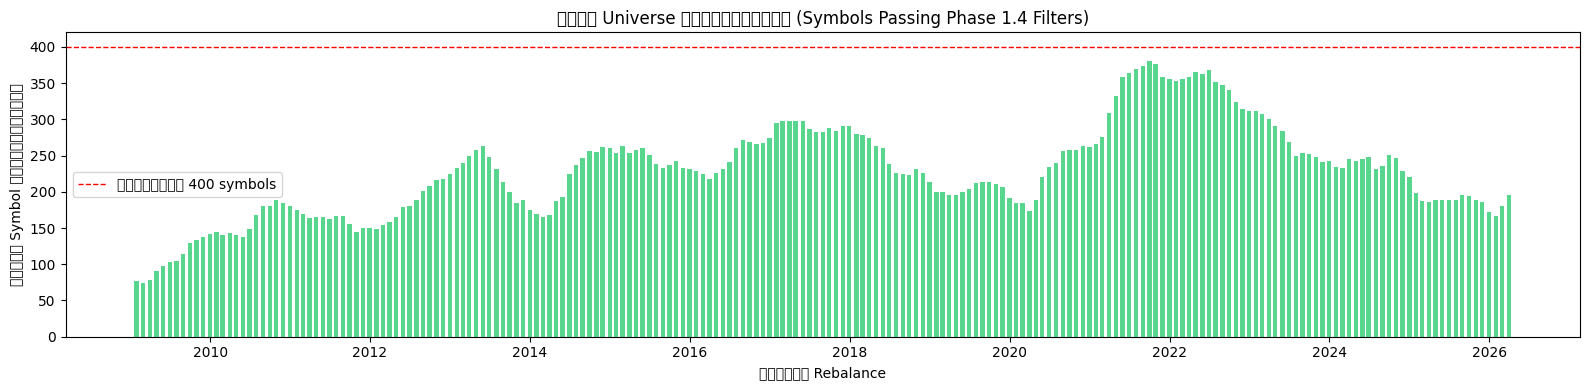

จำนวน Snapshot ทั้งหมด       : 207
ขนาด Universe ล่าสุด         : 196 symbols (2026-03-31)
ขนาด Universe เฉลี่ย         : 229 symbols
Snapshots ที่มี ≥400 symbols : 0 / 207


In [6]:
# Section 5 — Universe size over time
if not snapshot_keys:
    print("⚠ DATA NOT AVAILABLE — no universe snapshots found in data/universe/."
          " Run build_universe.py first.")
else:
    size_series: dict[str, int] = {}
    for key in snapshot_keys:
        try:
            snap_df = universe_store.load(key)
            date_str = key.split("/", 1)[-1]  # strip "universe/" prefix
            size_series[date_str] = len(snap_df)
        except Exception:
            continue

    sizes = pd.Series(size_series).sort_index()
    sizes.index = pd.to_datetime(sizes.index)

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.bar(sizes.index, sizes.values, width=20, color="#58D68D", edgecolor="none")
    ax.axhline(400, color="red", linewidth=1.0, linestyle="--", label="เป้าหมาย 400 symbols")
    ax.set_xlabel("วันที่ Rebalance")
    ax.set_ylabel("จำนวน Symbol ที่ผ่านเกณฑ์")
    ax.set_title("ขนาด Universe ตามช่วงเวลา (Symbols Passing Phase 1.4 Filters)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"จำนวน Snapshot ทั้งหมด       : {len(sizes)}")
    print(f"ขนาด Universe ล่าสุด         : {sizes.iloc[-1]} symbols ({sizes.index[-1].date()})")
    print(f"ขนาด Universe เฉลี่ย         : {sizes.mean():.0f} symbols")
    print(f"Snapshots ที่มี ≥400 symbols : {(sizes >= 400).sum()} / {len(sizes)}")

## ส่วนที่ 6: สรุปความครอบคลุมของข้อมูล

จัดกลุ่ม Symbol ตามความยาวของประวัติราคาในปฏิทิน (Calendar History Length):  
- **≥ 15 ปี** — ข้อมูลครบตาม `LOOKBACK_YEARS`
- **10–15 ปี** — ข้อมูลบางส่วน
- **< 10 ปี** — ข้อมูลสั้น (จดทะเบียนใหม่หรือดึงข้อมูลได้น้อย)

ความยาวประวัติคำนวณจาก `(วันที่มีราคาสุดท้าย − วันที่มีราคาแรก) / 365.25`

In [7]:
# Section 6 — Coverage summary (calendar history length buckets)
if not symbol_keys:
    print("⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.")
else:
    bucket_full: list[str] = []    # >= 15Y
    bucket_partial: list[str] = [] # 10-15Y
    bucket_short: list[str] = []   # < 10Y
    coverage_fracs: list[float] = []

    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].dropna()
            if len(close) < 2:
                bucket_short.append(key)
                coverage_fracs.append(0.0)
                continue

            # Calendar history length
            first_dt = close.index[0]
            last_dt = close.index[-1]
            history_years = (last_dt - first_dt).days / 365.25

            if history_years >= 15:
                bucket_full.append(key)
            elif history_years >= 10:
                bucket_partial.append(key)
            else:
                bucket_short.append(key)

            # Coverage fraction (consistent with UniverseBuilder.filter)
            total_bars = len(df["close"])
            valid_bars = int(df["close"].notna().sum())
            window = min(total_bars, LOOKBACK_YEARS * 252)
            coverage_fracs.append(valid_bars / window if window > 0 else 0.0)
        except Exception:
            bucket_short.append(key)
            coverage_fracs.append(0.0)

    total = len(symbol_keys)
    print("สรุปความครอบคลุมของข้อมูล (Coverage Summary)")
    print("=" * 52)
    print(f"{'กลุ่ม':<22} {'จำนวน':>8} {'สัดส่วน':>10}")
    print("-" * 42)
    print(f"{'≥ 15 ปี (ครบ LOOKBACK)':<22} {len(bucket_full):>8} "
          f"{len(bucket_full)/total*100:>9.1f}%")
    print(f"{'10–15 ปี (บางส่วน)':<22} {len(bucket_partial):>8} "
          f"{len(bucket_partial)/total*100:>9.1f}%")
    print(f"{'< 10 ปี (สั้น)':<22} {len(bucket_short):>8} "
          f"{len(bucket_short)/total*100:>9.1f}%")
    print("-" * 42)
    print(f"{'รวม':<22} {total:>8}")

    if coverage_fracs:
        median_cov = float(np.median(coverage_fracs))
        print(f"\nCoverage เฉลี่ย (median) : {median_cov:.2%}")
        print(f"เกณฑ์ MIN_DATA_COVERAGE  : {MIN_DATA_COVERAGE:.2%}")
        below = sum(1 for c in coverage_fracs if c < MIN_DATA_COVERAGE)
        print(f"Symbols ต่ำกว่าเกณฑ์    : {below} / {total} ({below/total*100:.1f}%)")

สรุปความครอบคลุมของข้อมูล (Coverage Summary)
กลุ่ม                     จำนวน    สัดส่วน
------------------------------------------
≥ 15 ปี (ครบ LOOKBACK)      391      56.3%
10–15 ปี (บางส่วน)           95      13.7%
< 10 ปี (สั้น)              208      30.0%
------------------------------------------
รวม                         694

Coverage เฉลี่ย (median) : 112.10%
เกณฑ์ MIN_DATA_COVERAGE  : 80.00%
Symbols ต่ำกว่าเกณฑ์    : 0 / 694 (0.0%)


## ส่วนที่ 7: การตรวจสอบและอนุมัติ (Sign-off)

ตรวจสอบเกณฑ์ทั้ง 6 ข้อ — ต้องผ่านทุกข้อก่อนเริ่ม Phase 2 (Signal Research)

| # | เกณฑ์ | ค่าที่ต้องการ |
|---|---|---|
| 1 | จำนวน symbol ดิบ | ≥ 400 |
| 2 | ประวัติดัชนี SET:SET | ≥ `LOOKBACK_YEARS × 252` bars |
| 3 | Median coverage | ≥ `MIN_DATA_COVERAGE` |
| 4 | Median avg daily turnover | ≥ `MIN_AVG_DAILY_VOLUME` THB |
| 5 | Universe snapshots | ≥ 1 snapshot |
| 6 | Symbol ที่มี 0 valid bars | = 0 |


In [8]:
# Section 7 — Sign-off: PASS/FAIL for all 6 exit criteria
PASS = "✓ PASS"
FAIL = "✗ FAIL"
NO_DATA = "✗ FAIL (NO DATA)"

results: list[tuple[str, str, str]] = []

# Criterion 1 — Raw symbol count >= 400
raw_count = len(symbol_keys)
c1 = PASS if raw_count >= 400 else (FAIL if raw_count > 0 else NO_DATA)
results.append(("1", f"Raw symbol count ≥ 400", f"{c1}  [{raw_count}]"))

# Criterion 2 — SET:SET index history >= LOOKBACK_YEARS * 252 bars
required_bars = LOOKBACK_YEARS * 252
try:
    index_df = raw_store.load("SET:SET")
    index_bars = int(index_df["close"].notna().sum())
    c2 = PASS if index_bars >= required_bars else FAIL
    results.append(("2", f"SET:SET bars ≥ {required_bars}", f"{c2}  [{index_bars}]"))
except KeyError:
    results.append(("2", f"SET:SET bars ≥ {required_bars}", f"{NO_DATA}  [not found]"))

# Criterion 3 — Median data coverage >= MIN_DATA_COVERAGE
cov_list: list[float] = []
zero_valid: list[str] = []
for key in symbol_keys:
    try:
        df_c = raw_store.load(key)
        total_bars_c = len(df_c["close"])
        valid_bars_c = int(df_c["close"].notna().sum())
        window_c = min(total_bars_c, LOOKBACK_YEARS * 252)
        cov = valid_bars_c / window_c if window_c > 0 else 0.0
        cov_list.append(cov)
        if valid_bars_c == 0:
            zero_valid.append(key)
    except Exception:
        cov_list.append(0.0)
        zero_valid.append(key)

if cov_list:
    med_cov = float(np.median(cov_list))
    c3 = PASS if med_cov >= MIN_DATA_COVERAGE else FAIL
    results.append(("3", f"Median coverage ≥ {MIN_DATA_COVERAGE:.0%}",
                    f"{c3}  [{med_cov:.2%}]"))
else:
    results.append(("3", f"Median coverage ≥ {MIN_DATA_COVERAGE:.0%}", NO_DATA))

# Criterion 4 — Median avg daily turnover >= MIN_AVG_DAILY_VOLUME
to_list: list[float] = []
for key in symbol_keys:
    try:
        df_t = raw_store.load(key)
        avg_c = float(df_t["close"].mean())
        avg_v = float(df_t["volume"].mean())
        if avg_c > 0 and avg_v > 0:
            to_list.append(avg_c * avg_v)
    except Exception:
        continue

if to_list:
    med_to = float(np.median(to_list))
    c4 = PASS if med_to >= MIN_AVG_DAILY_VOLUME else FAIL
    results.append(("4", f"Median turnover ≥ {MIN_AVG_DAILY_VOLUME:,.0f} THB",
                    f"{c4}  [{med_to:,.0f} THB]"))
else:
    results.append(("4", f"Median turnover ≥ {MIN_AVG_DAILY_VOLUME:,.0f} THB", NO_DATA))

# Criterion 5 — Universe snapshots present
snap_count = len(snapshot_keys)
c5 = PASS if snap_count >= 1 else (FAIL if symbol_keys else NO_DATA)
results.append(("5", "Universe snapshots ≥ 1", f"{c5}  [{snap_count}]"))

# Criterion 6 — No symbol with 0 valid bars
zero_count = len(zero_valid)
if not symbol_keys:
    c6 = NO_DATA
elif zero_count == 0:
    c6 = PASS
else:
    c6 = FAIL
results.append(("6", "No symbol with 0 valid bars", f"{c6}  [{zero_count} symbols]"))

# Print sign-off table
print("\n" + "=" * 72)
print(" PHASE 1.7 — DATA QUALITY SIGN-OFF")
print("=" * 72)
print(f"{'#':<4} {'เกณฑ์':<40} {'ผล':<30}")
print("-" * 72)
all_pass = True
for num, criterion, verdict in results:
    print(f"{num:<4} {criterion:<40} {verdict:<30}")
    if not verdict.startswith("✓"):
        all_pass = False
print("=" * 72)

if all_pass:
    print("\n✅ === ALL CHECKS PASSED — PHASE 1 SIGN-OFF COMPLETE ===\n")
    print("   ข้อมูลผ่านการตรวจสอบทั้งหมด พร้อมสำหรับ Phase 2 (Signal Research)")
else:
    print("\n❌ === SOME CHECKS FAILED — DO NOT PROCEED TO PHASE 2 ===\n")
    print("   แก้ไขปัญหาที่พบก่อน แล้ว Run notebook นี้ใหม่เพื่อยืนยัน")


 PHASE 1.7 — DATA QUALITY SIGN-OFF
#    เกณฑ์                                    ผล                            
------------------------------------------------------------------------
1    Raw symbol count ≥ 400                   ✓ PASS  [694]                 
2    SET:SET bars ≥ 3780                      ✓ PASS  [5200]                
3    Median coverage ≥ 80%                    ✓ PASS  [112.10%]             
4    Median turnover ≥ 1,000,000 THB          ✓ PASS  [11,192,262 THB]      
5    Universe snapshots ≥ 1                   ✓ PASS  [207]                 
6    No symbol with 0 valid bars              ✓ PASS  [0 symbols]           

✅ === ALL CHECKS PASSED — PHASE 1 SIGN-OFF COMPLETE ===

   ข้อมูลผ่านการตรวจสอบทั้งหมด พร้อมสำหรับ Phase 2 (Signal Research)
